In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Malgun Gothic'   # 맑은 고딕
mpl.rcParams['axes.unicode_minus'] = False      # 마이너스 깨짐 방지

In [3]:
import torch
from torchviz import make_dot
import numpy as np

# 4.7 활성화 함수의 목적

### 학습용 데이터 계산

In [17]:
# 훈련 데이터, 검증 데이터 계산
np.random.seed(123)
x = np.random.randn(100,1)

# y는 x^2에 난수를 1/10만큼 더한 값
y = x**2 + np.random.randn(100,1) * 0.1

# 데이터를 50건씩 훈련용과 검증용으로 나눔
x_train = x[:50,:]
x_test = x[50:,:]
y_train = y[:50,:]
y_test = y[50:,:]

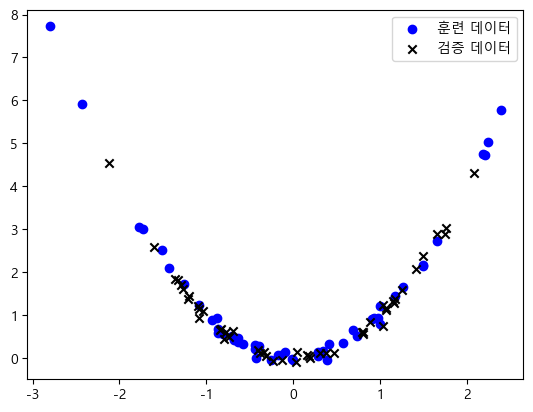

In [18]:
# 산포도 출력
plt.scatter(x_train, y_train, c='b', label='훈련 데이터')
plt.scatter(x_test, y_test, c='k', marker = 'x', label='검증 데이터')
plt.legend()
plt.show()

In [19]:
# 입력 변수 x와 정답 yt의 텐서화
inputs = torch.tensor(x_train).float()
labels = torch.tensor(y_train).float()

inputs_test = torch.tensor(x_test).float()
labels_test = torch.tensor(y_test).float()

In [20]:
import torch.optim as optim

### 선형 회귀 모델의 경우



어디가에서 forward 만하고 backward는 안하는데 그 이유가 pytorch가 미분까지 자동으로 하기 때문

In [21]:
import torch.nn as nn

In [22]:
# 모델 정의
class Net(nn.Module):
    def __init__(self):
        
        # 부모 클래스 nn.Module의 초기화 
        super().__init__()
        
        # 출력층 정의
        self.l1 = nn.Linear(1, 1)
        
    # 예측 함수 정의
    def forward(self, x):
        x1 = self.l1(x) # 선형 회귀
        return x1

In [23]:
# 학습률
lr = 0.01

# 인스턴스 생성(파라미터 초기화)
net = Net()

# 최적화 알고리즘 : 경사 하강법
optimizer = optim.SGD(net.parameters(), lr=lr)

# 손실 함수 : 평균 제곱 오차
criterion = nn.MSELoss()

# 반복 횟수
num_epochs = 10000

# history 기록을 위한 배열 초기화(손실 함수 값 만을 기록)
history = np.zeros((0,2))

In [24]:
# 반복 계산 메인 루프
for epoch in range(num_epochs):
    
    # 경사 값 초기화
    optimizer.zero_grad()
    
    # 예측 계산
    outputs = net(inputs)
    
    # 오차 계산
    loss = criterion(outputs, labels)
    
    # 경사 계산
    loss.backward()
    
    # 경사 하강법 적용
    optimizer.step()
    
    # 100회 마다 도중 경과를 기록
    if (epoch % 100 == 0):
        history = np.vstack((history, np.array([epoch, loss.item()])))
        print(f'Epoch {epoch} loss : {loss.item():.5f}')

Epoch 0 loss : 3.94753
Epoch 100 loss : 3.22825
Epoch 200 loss : 3.21567
Epoch 300 loss : 3.21545
Epoch 400 loss : 3.21544
Epoch 500 loss : 3.21544
Epoch 600 loss : 3.21544
Epoch 700 loss : 3.21544
Epoch 800 loss : 3.21544
Epoch 900 loss : 3.21544
Epoch 1000 loss : 3.21544
Epoch 1100 loss : 3.21544
Epoch 1200 loss : 3.21544
Epoch 1300 loss : 3.21544
Epoch 1400 loss : 3.21544
Epoch 1500 loss : 3.21544
Epoch 1600 loss : 3.21544
Epoch 1700 loss : 3.21544
Epoch 1800 loss : 3.21544
Epoch 1900 loss : 3.21544
Epoch 2000 loss : 3.21544
Epoch 2100 loss : 3.21544
Epoch 2200 loss : 3.21544
Epoch 2300 loss : 3.21544
Epoch 2400 loss : 3.21544
Epoch 2500 loss : 3.21544
Epoch 2600 loss : 3.21544
Epoch 2700 loss : 3.21544
Epoch 2800 loss : 3.21544
Epoch 2900 loss : 3.21544
Epoch 3000 loss : 3.21544
Epoch 3100 loss : 3.21544
Epoch 3200 loss : 3.21544
Epoch 3300 loss : 3.21544
Epoch 3400 loss : 3.21544
Epoch 3500 loss : 3.21544
Epoch 3600 loss : 3.21544
Epoch 3700 loss : 3.21544
Epoch 3800 loss : 3.2154

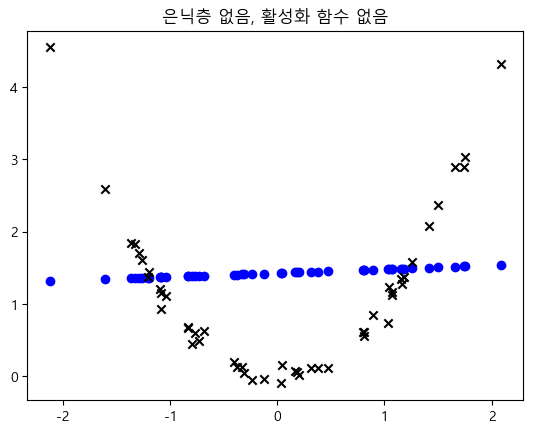

In [25]:
# 결과 그래프
labels_pred = net(inputs_test)

plt.title('은닉층 없음, 활성화 함수 없음')
plt.scatter(inputs_test[:,0].data, labels_pred[:,0].data, c='b', label='예측값')
plt.scatter(inputs_test[:,0].data, labels_test[:,0].data, c='k', marker = 'x', label='정답(검증 데이터)')

### 유사 딥러닝 모델의 경우

In [26]:
# 모델 정의

class Net2(nn.Module):
    def __init__(self):
        #  부모 클래스 nn.Modules 초기화
        super().__init__()

        # 출력층 정의
        self.l1 = nn.Linear(1, 10)
        self.l2 = nn.Linear(10, 10)
        self.l3 = nn.Linear(10,1)
        
    # 예측 함수 정의
    def forward(self, x):
        x1 = self.l1(x)
        x2 = self.l2(x1)
        x3 = self.l3(x2)
        return x3

In [27]:
# 학습률
lr = 0.01

# 인스턴스 생성(파라미터 초기화)
net2 = Net2()

# 최적화 알고리즘 : 경사 하강법
optimizer = optim.SGD(net2.parameters(), lr=lr)

# 손실 함수 : 평균 제곱 오차
criterion = nn.MSELoss()

# 반복 횟수
num_epochs = 10000

# history 기록을 위한 배열 초기화(손실 함수 값 만을 기록)
history = np.zeros((0,2))

In [28]:
# 반복 계산 메인 루프

for epoch in range(num_epochs):
    
    # 경사 값 초기화
    optimizer.zero_grad()
    
    # 예측 계산
    outputs = net2(inputs)
    
    # 오차 계산
    loss = criterion(outputs, labels)
    
    # 경사 계산
    loss.backward()
    
    # 경사 하강법 적용
    optimizer.step()
    
    # 100회 마다 도중 경과를 기록
    if (epoch % 100 == 0):
        history = np.vstack((history, np.array([epoch, loss.item()])))
        print(f'Epoch{epoch} loss : {loss.item():.5f}')

Epoch0 loss : 4.71717
Epoch100 loss : 3.21544
Epoch200 loss : 3.21544
Epoch300 loss : 3.21544
Epoch400 loss : 3.21544
Epoch500 loss : 3.21544
Epoch600 loss : 3.21544
Epoch700 loss : 3.21544
Epoch800 loss : 3.21544
Epoch900 loss : 3.21544
Epoch1000 loss : 3.21544
Epoch1100 loss : 3.21544
Epoch1200 loss : 3.21544
Epoch1300 loss : 3.21544
Epoch1400 loss : 3.21544
Epoch1500 loss : 3.21544
Epoch1600 loss : 3.21544
Epoch1700 loss : 3.21544
Epoch1800 loss : 3.21544
Epoch1900 loss : 3.21544
Epoch2000 loss : 3.21544
Epoch2100 loss : 3.21544
Epoch2200 loss : 3.21544
Epoch2300 loss : 3.21544
Epoch2400 loss : 3.21544
Epoch2500 loss : 3.21544
Epoch2600 loss : 3.21544
Epoch2700 loss : 3.21544
Epoch2800 loss : 3.21544
Epoch2900 loss : 3.21544
Epoch3000 loss : 3.21544
Epoch3100 loss : 3.21544
Epoch3200 loss : 3.21544
Epoch3300 loss : 3.21544
Epoch3400 loss : 3.21544
Epoch3500 loss : 3.21544
Epoch3600 loss : 3.21544
Epoch3700 loss : 3.21544
Epoch3800 loss : 3.21544
Epoch3900 loss : 3.21544
Epoch4000 lo

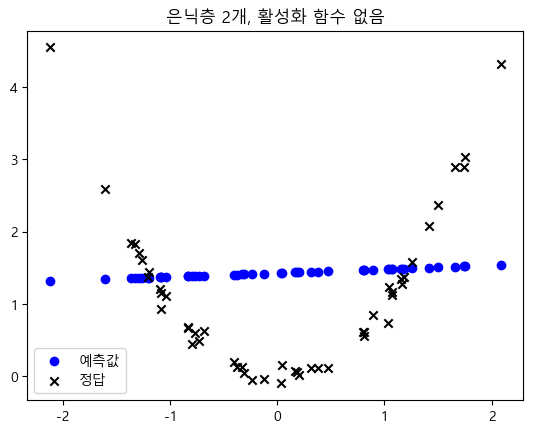

In [29]:
# 결과 그래프
labels_pred2 = net2(inputs_test)

plt.title('은닉층 2개, 활성화 함수 없음')
plt.scatter(inputs_test[:,0].data, labels_pred2[:,0].data, c='b', label='예측값')
plt.scatter(inputs_test[:,0].data, labels_test[:,0].data, c='k', marker = 'x', label='정답')
plt.legend()
plt.show()

### 딥러닝 모델(활성화 함수 사용)의 경우

In [32]:
# 모델 정의

class Net3(nn.Module):
    def __init__(self):
        # 부모 클래스 nn.Module 초기화
        super().__init__()
        
        # 출력층 정의
        self.l1 = nn.Linear(1, 10)
        self.l2 = nn.Linear(10, 10)
        self.l3 = nn.Linear(10,1)
        self.relu = nn.ReLU(inplace=True)
        
    # 예측 함수 정의
    def forward(self, x):
        x1 = self.relu(self.l1(x))
        x2 = self.relu(self.l2(x1))
        x3 = self.l2(x2)
        return x3

In [33]:
# 학습률
lr = 0.01  

# 인스턴스 생성(파라미터 초기화)
net3 = Net3()

# 최적화 알고리즘 : 경사 하강법
optimizer = optim.SGD(net3.parameters(), lr=lr)

# 손실 함수 : 평균 제곱 오차
criterion = nn.MSELoss()

# 반복 횟수
num_epochs = 10000

# history 기록을 위한 배열 초기화(손실 함수 값 만을 기록)
history = np.zeros((0,2))

In [34]:
# 반복 계산 메인 루프

for epoch in range(num_epochs):
    
    # 경사 값 초기화
    optimizer.zero_grad()

    # 예측 계산
    outputs = net3(inputs)
  
    # 오차 계산
    loss = criterion(outputs, labels)

    # 경사 계산
    loss.backward()

    # 경사 하강법 적용
    optimizer.step()

    # 100회 마다 도중 경과를 기록
    if ( epoch % 100 == 0):
        history = np.vstack((history, np.array([epoch, loss.item()])))
        print(f'Epoch {epoch} loss: {loss.item():.5f}')

d:\CV\venv\Lib\site-packages\torch\nn\modules\loss.py:626: UserWarning: Using a target size (torch.Size([50, 1])) that is different to the input size (torch.Size([50, 10])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch 0 loss: 5.11321
Epoch 100 loss: 2.99464
Epoch 200 loss: 1.54232
Epoch 300 loss: 0.42368
Epoch 400 loss: 0.16704
Epoch 500 loss: 0.10422
Epoch 600 loss: 0.08007
Epoch 700 loss: 0.06634
Epoch 800 loss: 0.05826
Epoch 900 loss: 0.05246
Epoch 1000 loss: 0.04807
Epoch 1100 loss: 0.04428
Epoch 1200 loss: 0.04127
Epoch 1300 loss: 0.03856
Epoch 1400 loss: 0.03609
Epoch 1500 loss: 0.03372
Epoch 1600 loss: 0.03136
Epoch 1700 loss: 0.02931
Epoch 1800 loss: 0.02768
Epoch 1900 loss: 0.02622
Epoch 2000 loss: 0.02499
Epoch 2100 loss: 0.02404
Epoch 2200 loss: 0.02302
Epoch 2300 loss: 0.02200
Epoch 2400 loss: 0.02115
Epoch 2500 loss: 0.02045
Epoch 2600 loss: 0.01994
Epoch 2700 loss: 0.01948
Epoch 2800 loss: 0.01903
Epoch 2900 loss: 0.01864
Epoch 3000 loss: 0.01831
Epoch 3100 loss: 0.01802
Epoch 3200 loss: 0.01771
Epoch 3300 loss: 0.01741
Epoch 3400 loss: 0.01715
Epoch 3500 loss: 0.01692
Epoch 3600 loss: 0.01668
Epoch 3700 loss: 0.01644
Epoch 3800 loss: 0.01600
Epoch 3900 loss: 0.01544
Epoch 4000 l

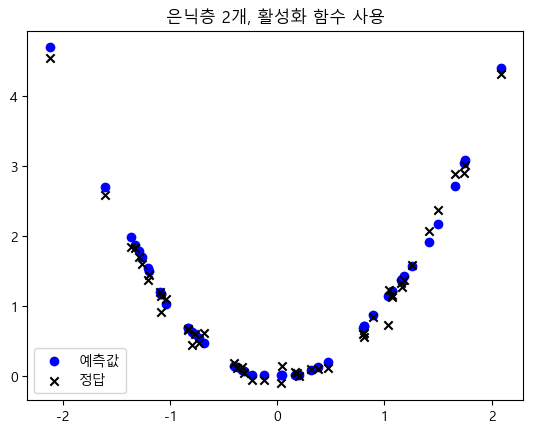

In [35]:
# 결과 그래프
labels_pred3 = net3(inputs_test)

plt.title('은닉층 2개, 활성화 함수 사용')
plt.scatter(inputs_test[:,0].data, labels_pred3[:,0].data, c='b', label='예측값')
plt.scatter(inputs_test[:,0].data, labels_test[:,0].data, c='k', marker='x',label='정답')
plt.legend()
plt.show()
